# Predikcija unapredjenja zaposlenih primenom tehnika masinskog ucenja

Cilj projekta je primena masinskog ucenja za predvidjanje unapredjenja zaposlenih na osnovu njihovih demografskih i profesionalnih karakteristika. Problem je formulisan kao zadatak binarne klasifikacije, gde ciljno obelezje oznacava da li je zaposleni unapredjen ili ne. Primenom tehnika masinskog ucenja nastojimo da otkrijemo obrasce u podacima i identifikujemo kljucne faktore koji uticu na unapredjenje. 

Poseban fokus projekta je stavljen na resavanje problema neuravnotezenosti klasa, gde procenat unapredjenih radnika cini oko 9%. Kroz rad su primenjene razlicite tehnike resavanja nebalansiranosti podataka uz odgovarajuce modele, sa ciljem kreiranja pouzdanog modela za predikciju unapredjenja.

In [715]:
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

### Koriscene biblioteke

In [716]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_fscore_support
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

%matplotlib inline

## Ucitavanje i opis podataka 

Ucitavanje podataka i prikaz osnovnih informacija

In [717]:
df = pd.read_csv('data/data.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


Skup podataka cini 54808 zapisa sa 13 atributa i sadrzi demografske i profesionalne informacije o zaposlenima, kao i ciljno obelezje `is_promoted` koje oznacava da li je zaposleni unapredjen. Prisutan je veci broj numerickih i kategorijskih atributa, sto zahteva odgovarajuce pretprocesiranje pre primene modela masinskog ucenja.

### Kvalitet podataka
Pre dalje analize i modelovanja, neophodno je proveriti kvalitet podataka, ukljucujuci prisustvo nedostajucih vrednosti i eventualnih duplikata.

In [718]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [719]:
df.duplicated().sum()

np.int64(0)

Primetno je prisustvo nedostajucih vrednosti atributa `education` i `previous_year_rating`, sto zahteva primenu odgovarajucih tehnika imputacije u fazi pretprocesiranja. Skup podataka ne sadrzi duplikate.

### Analiza ciljne promenljive
U ovoj sekciji se nalazi analiza raspodele ciljne promenljive `is_promoted`. Razumevanje odnosa izmedju klasa je kljucno za izbor odgovarajucih tehnika balansiranja podataka i evaluacije modela.

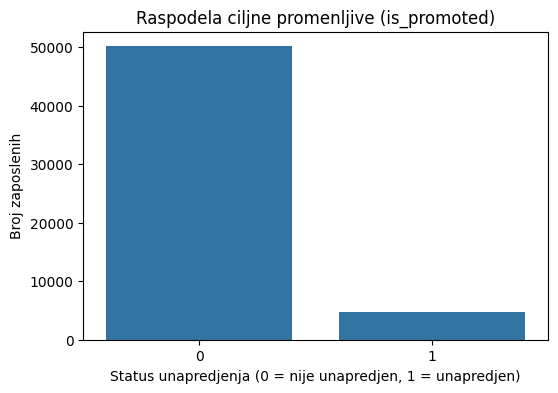

is_promoted
0    91.482995
1     8.517005
Name: proportion, dtype: float64

In [720]:
plt.figure(figsize=(6, 4))
sns.countplot(x="is_promoted", data=df)
plt.title("Raspodela ciljne promenljive (is_promoted)")
plt.xlabel("Status unapredjenja (0 = nije unapredjen, 1 = unapredjen)")
plt.ylabel("Broj zaposlenih")
plt.show()
df['is_promoted'].value_counts(normalize=True) * 100

Analiza raspodele ciljne promenljive pokazuje izrazenu nebalansiranost klasa, pri cemu znatno veci broj zaposlenih nije unapredjen u odnosu na one koji jesu. Ovakva struktura podataka moze dovesti do toga da modeli favorizuju vecinsku klasu.
Zbog toga ce u nastavku rada biti primenjena SMOTE tehnika za balansiranje podataka iskljucivo nad trening skupom, dok ce se kao glavna metrika za evaluaciju performansi koristiti F1-score, koji daje uravnotezenu meru izmedju preciznosti i odziva i omogucava realniju procenu performansi modela u ovakvim uslovima.

## Eksplorativna analiza relevantnih atributa
U ovoj sekciji je prikazana analiza atributa za koje se na osnovu domenskog znanja i preliminarne analize, može ocekivati da imaju znacajan uticaj na unapredjenje zaposlenih. Cilj ove analize je identifikacija potencijalno relevantnih faktora za dalje modelovanje.

## Uticaj profesionalnih atributa 

### Prethodna ocena rada

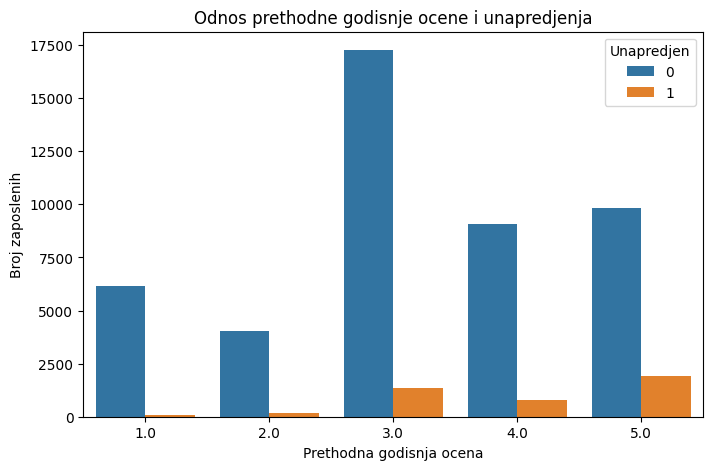

In [721]:
plt.figure(figsize=(8, 5))
sns.countplot(x="previous_year_rating", hue="is_promoted", data=df)
plt.title("Odnos prethodne godisnje ocene i unapredjenja")
plt.xlabel("Prethodna godisnja ocena")
plt.ylabel("Broj zaposlenih")
plt.legend(title="Unapredjen")
plt.show()

Uocava se jasna povezanost izmedju vise prethodne godisnje ocene i vece verovatnoce unapredjenja, sto ukazuje da je ovaj atribut jedan od kljucnih faktora u procesu donosenja odluka o unapredjenju.

### Rezultat obuke

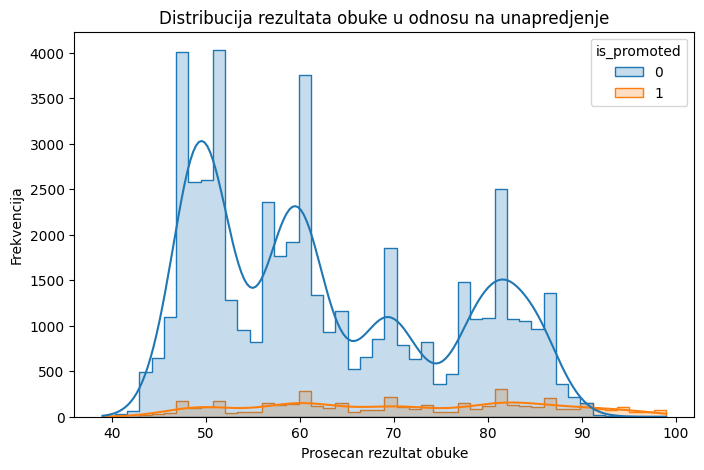

In [722]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="avg_training_score", hue="is_promoted", kde=True, element="step")
plt.title("Distribucija rezultata obuke u odnosu na unapredjenje")
plt.xlabel("Prosecan rezultat obuke")
plt.ylabel("Frekvencija")
plt.show()

Zaposleni sa visim rezultatima obuka imaju vecu ucestalost unapredjenja, sto potvrdjuje znacaj kontinuiranog usavrsavanja u procesu napredovanja.

### Nagrade

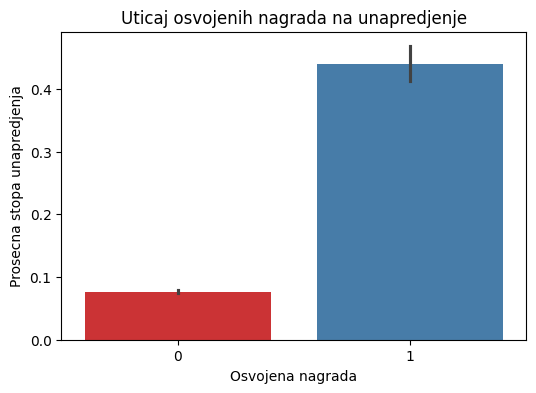

In [723]:
plt.figure(figsize=(6, 4))
sns.barplot(x="awards_won?", y="is_promoted", data=df, hue="awards_won?", palette="Set1", legend=False)
plt.title("Uticaj osvojenih nagrada na unapredjenje")
plt.xlabel("Osvojena nagrada")
plt.ylabel("Prosecna stopa unapredjenja")
plt.show()

Zaposleni koji su osvojili nagrade imaju znatno vecu prosecnu stopu unapredjenja, sto ukazuje na snazan pozitivan uticaj ovog atributa.

### Godine radnog staza

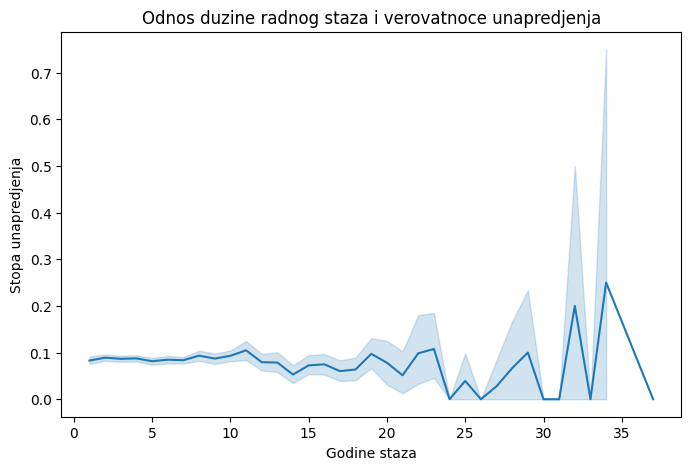

In [724]:
plt.figure(figsize=(8, 5))
sns.lineplot(x="length_of_service", y="is_promoted", data=df)
plt.title("Odnos duzine radnog staza i verovatnoce unapredjenja")
plt.xlabel("Godine staza")
plt.ylabel("Stopa unapredjenja")
plt.show()

Verovatnoca unapredjenja raste sa godinama staza do odredjene tacke, nakon cega se stabilizuje, sto ukazuje na nelinearnu zavisnost ovog atributa.

Na osnovu selektivne eksplorativne analize moze se zakljuciti da atributi kao sto su prethodna godisnja ocena, rezultati obuka, osvojene nagrade i duzina radnog staza imaju znacajan uticaj na verovatnocu unapredjenja.

## Demografski faktori

### Starost

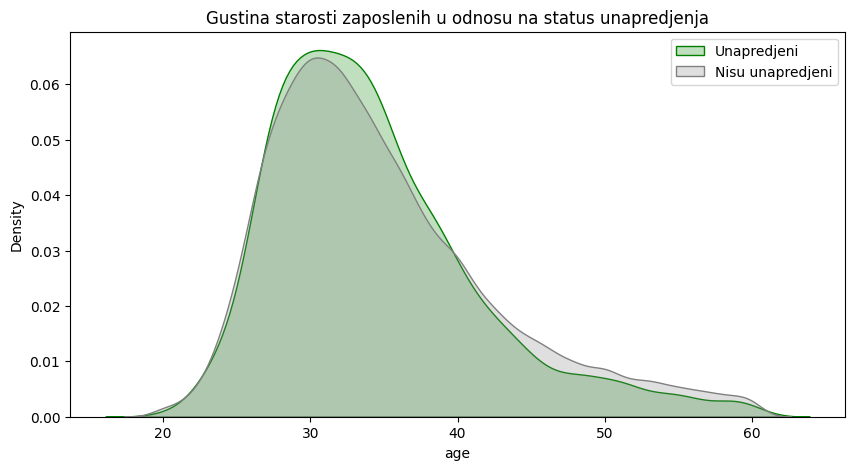

In [725]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['is_promoted'] == 1], x='age', label='Unapredjeni', fill=True, color='green')
sns.kdeplot(data=df[df['is_promoted'] == 0], x='age', label='Nisu unapredjeni', fill=True, color='grey')
plt.title('Gustina starosti zaposlenih u odnosu na status unapredjenja')
plt.legend()
plt.show()

### Pol

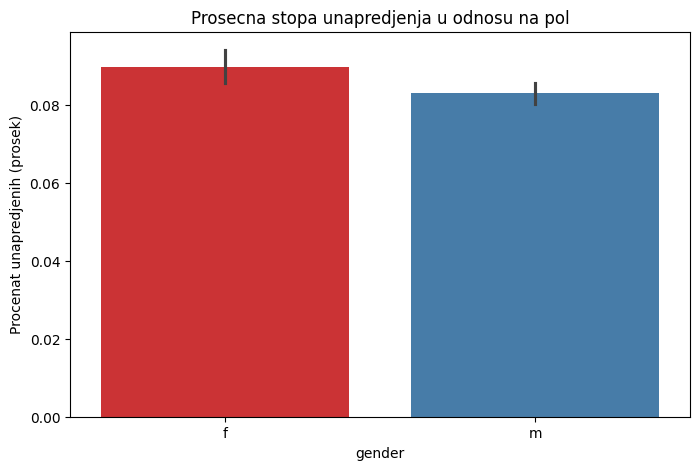

In [726]:
plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='is_promoted', data=df, hue='gender', palette='Set1', legend=False)
plt.title('Prosecna stopa unapredjenja u odnosu na pol')
plt.ylabel('Procenat unapredjenih (prosek)')
plt.show()

### Obrazovanje

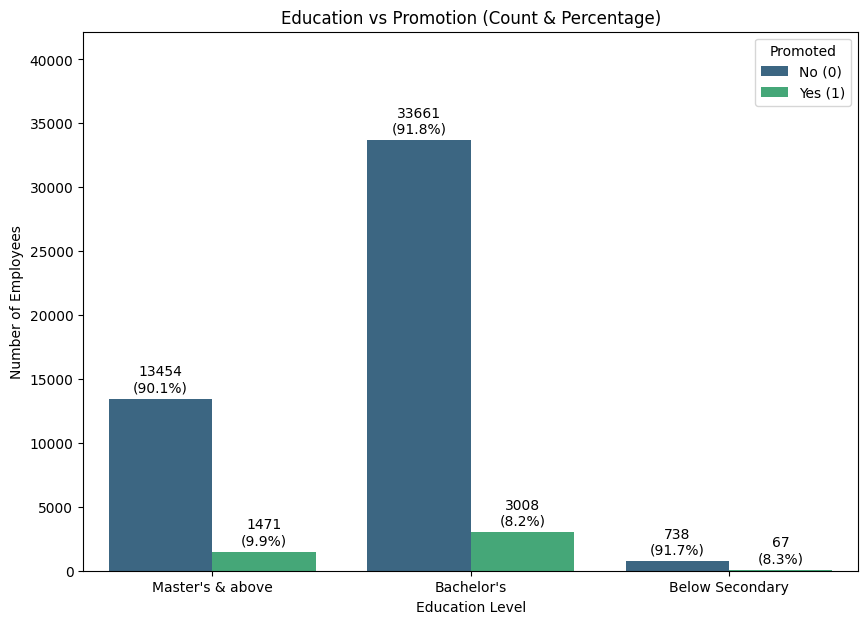

In [727]:
plt.figure(figsize=(10, 7))
ax = sns.countplot(x="education", hue="is_promoted", data=df, palette='viridis')

total_per_edu = df.groupby('education').size()
edu_order = [label.get_text() for label in ax.get_xticklabels()]

for container in ax.containers:
    labels = []
    for i, v in enumerate(container):
        count = v.get_height()
        if count > 0:
            edu_name = edu_order[i]
            total = total_per_edu[edu_name]
            percentage = (count / total) * 100
            labels.append(f'{int(count)}\n({percentage:.1f}%)')
        else:
            labels.append('0 (0.0%)')
    
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title("Education vs Promotion (Count & Percentage)")
plt.xlabel("Education Level")
plt.ylabel("Number of Employees")
plt.legend(title='Promoted', labels=['No (0)', 'Yes (1)'])
plt.ylim(0, df['education'].value_counts().max() * 1.15)
plt.show()

Analiza demografskih atributa ukazuje da starost, nivo obrazovanja i pol pokazuju odredjene razlike u stopama unapredjenja, ali bez izrazitih diskontinuiteta izmedju grupa. U poredjenju sa profesionalnim atributima, njihov uticaj deluje slabije izrazen. Iz tog razloga, demografski faktori ce biti ukljuceni u dalje modelovanje, ali se ne ocekuje da imaju dominantan doprinos u predikciji unaprecjenja.

---

# Pretprocesiranje podataka

## Definisanje ulaznih i izlazne promenljive

Cilj modela je predvidjanje da li je zaposleni unapredjen, sto predstavlja vrednost ciljne promenljive `is_promoted`. Svi ostali atributi predstavljaju ulazne promenljive na osnovu kojih modeli uce obrasce.

Pre pretprocesiranja se vrsi razdvajanje ulaza i izlaza da bi se izbeglo nenamerno koriscenje ciljne promenljive u imputaciji i transformacijama i da bi se omogucila pravilna primena tehnika kao sto su SMOTE i skaliranje iskljucivo nad ulazima.

In [728]:
X = df.drop('is_promoted', axis=1)
y = df['is_promoted']

Na ovaj nacin su razdvojeni podaci koje modeli koriste za ucenje (`X`) i tacni odgovori (`y`), sto je neophodno za ispravno treniranje i evaluaciju modela.

## Uklanjanje neinformativnih atributa

Kolona `employee_id` predstavlja jedinstveni identifikator zaposlenog i ne sadrzi informaciju relevantnu za proces unapredjenja. Njeno zadrzavanje moze dovesti do laznih obrazaca, pa se uklanja iz daljeg razmatranja.

In [729]:
X = X.drop('employee_id', axis=1)

Uklanjanjem identifikatora sprecava se da modeli uce irelevantne ili slucajne obrasce.

## Podela podataka na trening i test skup

Podaci se dele u odnosu 70:30, pri cemu se:
- trening skup koristi za ucenje i optimizaciju modela,
- test skup cuva netaknut za konacnu evaluaciju.

Stratifikacija po ciljnoj promenljivoj se koristi zbog izrazene klasne neravnoteze.

In [730]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [731]:
# dimenzije podataka pre imputacije, test ostaje nepromenjen
print("X_train_res shape:", X_train.shape)
print("y_train_res shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train_res shape: (38365, 11)
y_train_res shape: (38365,)
X_test shape: (16443, 11)
y_test shape: (16443,)


Ovim pristupom obezbedjena je objektivna procena performansi modela.

## Razdvajanje numerickih i kategorijskih atributa

Razlicite vrste atributa zahtevaju razlicite tehnike pretprocesiranja:
- numericki atributi zahtevaju imputaciju i skaliranje
- kategorijski atributi zahtevaju imputaciju i kodiranje
- edukacija, iako kategorijski atribut, je izdvojena zbog posebne obrade

Zbog toga se atributi razdvajaju po tipu.

In [732]:
num_cols = [
    'age',
    'no_of_trainings',
    'previous_year_rating',
    'length_of_service',
    'avg_training_score',
    'awards_won?'
]

cat_cols = [
    'department',
    'region',
    'gender',
    'recruitment_channel'
]

education = [
    'education'
]

In [733]:
print(X_train['education'].unique())

["Bachelor's" "Master's & above" nan 'Below Secondary']


Ova podela omogucava obradu podataka uskladjenu sa tipom.

## Imputacija nedostajucih vrednosti

S obzirom na umeren procenat nedostajucih vrednosti, podaci nisu uklanjani.
Primenjena je kontrolisana imputacija:
- numericke vrednosti zamenjuju se medianom,
- kategorijske vrednosti se zamenjuju novom kategorijom 'Unknown'.

In [734]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

X_train[['education']] = cat_imputer.fit_transform(X_train[['education']])
X_test[['education']] = cat_imputer.transform(X_test[['education']])

Upotrebom metoda fit_transform() na trening skupom i transform() nad test skupom odradjena je imputacija nedostajucih vrednosti, a ovaj pristup sprecava curenje informacija iz test skupa.

## Kodiranje kategorijskih atributa

Za kodiranje kategorijskih atributa promenjena je One-Hot Encoding metoda, pri cemu se svaka kategorija transformise u binarnu promenjivu, cime se izbegava uvodjenje vestackog redosleda izmedju kategorija, sto je vazno za modele koji pretpostavljaju linearnu zavisnost izmedju ulaznih promenjivih i ciljne promenjive kao sto radi logisticka regresija. 


Atribut education nije kodiran One-Hot metodom, već ordinalnim kodiranjem, jer poseduje prirodan redosled nivoa obrazovanja (Other < Bachelor's < Master's & above). Kategorija 'Unknown' mapirana je na najniži nivo, jer predstavlja nedostajuće ili nedefinisane vrednosti.

In [735]:
education_mapping = {
    'Other': 0,
    'Unknown': 0,
    'Below Secondary': 0,
    "Bachelor's": 1,
    "Master's & above": 2
}

X_train['education'] = X_train['education'].map(education_mapping)
X_test['education'] = X_test['education'].map(education_mapping)

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

Nakon kodiranja uradjeno je uskladjivanje trening i test skupa kako bi oba skupa imala identicnu strukturu kolona, zbog omogucavanja konzistentnosti ulaznih podataka tokom treninga i evaluacije.

In [736]:
print(X_train.isnull().sum().sum())  
print(X_test.isnull().sum().sum()) 

0
0


## Korelaciona matrica

U cilju ispitivanja međusobnih odnosa između numeričkih atributa, izračunata je korelaciona matrica.

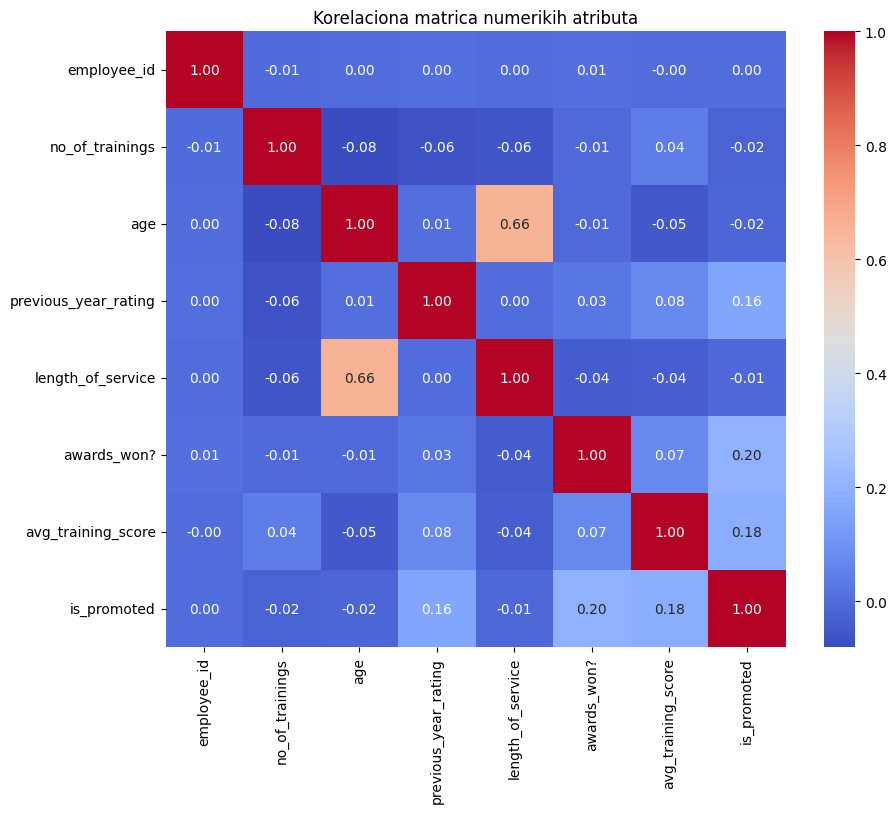

In [737]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelaciona matrica numerikih atributa")
plt.show()

Na osnovu prikazane matrice može se uočiti da većina atributa nema jaku međusobnu korelaciju, što ukazuje na nizak stepen multikolinearnosti. Najizraženije veze primećuju se između pojedinih profesionalnih atributa i ciljne promenljive, posebno kod atributa previous_year_rating, avg_training_score i awards_won? što dodatno potvrđuje njihov značaj u procesu predikcije unapređenja.

## Skaliranje numerickih atributa

Skaliranje se primenjuje zbog logisticke regresije, koja je osetljiva na razlicite razmere atributa. Za modele zasnovane na stablima skaliranje nije neophodno, ali se zadrzava radi konzistentnosti.

In [740]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Skalirani podaci omogucavaju stabilnije i uporedive rezultate modela.

## Balansiranje klasa

Zbog izražene neravnoteže u ciljnoj promenljivoj, gde samo oko 9% zaposlenih pripada klasi unapređenih, primena tehnika balansiranja podataka predstavlja ključan korak u procesu modelovanja.

U ovom radu primenjene su tri različite metode balansiranja:
- **SMOTE** (Synthetic Minority Over-sampling Technique) – generiše nove sintetičke uzorke manjinske klase
- **ROS** (Random OverSampling) – nasumično duplira postojeće uzorke manjinske klase
- **SMOTE-Tomek** (SMOTE + Tomek Links) – kombinuje generisanje novih uzoraka sa uklanjanjem preklapajućih instanci između klasa

Cilj je ispitati kako razlicite tehnike balansiranja uticu na performanse modela, sto ce biti mereno uporedjivanjem f1-score.
Zbog izrazene klasne neravnoteze, tehnike se primenjuju iskljucivo nad trening skupom kako bi se sprecilo curenje informacija iz test skupa.

In [741]:
#SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [742]:
#ROS
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

In [743]:
# SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)

Na ovaj nacin modeli dobijaju uravnotezen trening skup, dok test skup ostaje nepromenjen.

### Provera dimenzija podataka nakon pretprocesiranja

In [744]:
print("SMOTE:")
print("X_train_smote shape:", X_train_smote.shape)
print("y_train_smote shape:", y_train_smote.shape, "\n")

print("Random OverSampling:")
print("X_train_ros shape:", X_train_ros.shape)
print("y_train_ros shape:", y_train_ros.shape, "\n")

print("SMOTE-Tomek:")
print("X_train_st shape:", X_train_st.shape)
print("y_train_st shape:", y_train_st.shape, "\n")

print("Test skup:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

SMOTE:
X_train_smote shape: (70194, 51)
y_train_smote shape: (70194,) 

Random OverSampling:
X_train_ros shape: (70194, 51)
y_train_ros shape: (70194,) 

SMOTE-Tomek:
X_train_st shape: (69888, 51)
y_train_st shape: (69888,) 

Test skup:
X_test shape: (16443, 51)
y_test shape: (16443,)


Broj redova u trening skupovima je povecan zbog primene tehnika balansiranja. Nakon primene SMOTE-Tomek metode dolazi do blagog smanjenja broja uzoraka u odnosu na SMOTE i ROS, jer se nakon generisanja dodatnih uzoraka uklanjaju Tomek linkovi, odnosno primeri koji se nalaze na granici izmedju klasa i mogu predstavljati sum ili preklapanje klasa.

Test skup je ostao nepromenjen da bi se zadrzala distribucija klasa. 

### Provera balansiranosti klasa u trening skupu

Provera raspodela ciljnih klasa u trening skupu nakon primene SMOTE tehnike.

In [745]:
print("Raspodela klasa u SMOTE trening skupu (%):")
print(pd.Series(y_train_smote).value_counts(normalize=True) * 100)

print("\nRaspodela klasa u ROS trening skupu (%):")
print(pd.Series(y_train_ros).value_counts(normalize=True) * 100)

print("\nRaspodela klasa u SMOTE-Tomek trening skupu (%):")
print(pd.Series(y_train_st).value_counts(normalize=True) * 100)

Raspodela klasa u SMOTE trening skupu (%):
is_promoted
0    50.0
1    50.0
Name: proportion, dtype: float64

Raspodela klasa u ROS trening skupu (%):
is_promoted
0    50.0
1    50.0
Name: proportion, dtype: float64

Raspodela klasa u SMOTE-Tomek trening skupu (%):
is_promoted
0    50.0
1    50.0
Name: proportion, dtype: float64


Trening skup je balansiran.

### Provera da nema nedostajucih vrednosti

In [746]:
print("Nedostajuće vrednosti u test skupu:")
print("X_test:", X_test.isnull().sum().sum())
print("y_test:", pd.Series(y_test).isnull().sum())
print()

print("Nedostajuće vrednosti u treninzima nakon balansiranja klasa:")

print("SMOTE:")
print("X_train_smote:", X_train_smote.isnull().sum().sum())
print("y_train_smote:", pd.Series(y_train_smote).isnull().sum())
print()

print("Random OverSampling:")
print("X_train_ros:", X_train_ros.isnull().sum().sum())
print("y_train_ros:", pd.Series(y_train_ros).isnull().sum())
print()

print("SMOTE-Tomek:")
print("X_train_st:", X_train_st.isnull().sum().sum())
print("y_train_st:", pd.Series(y_train_st).isnull().sum())

Nedostajuće vrednosti u test skupu:
X_test: 0
y_test: 0

Nedostajuće vrednosti u treninzima nakon balansiranja klasa:
SMOTE:
X_train_smote: 0
y_train_smote: 0

Random OverSampling:
X_train_ros: 0
y_train_ros: 0

SMOTE-Tomek:
X_train_st: 0
y_train_st: 0


## Uvid u konacni izgled podataka

Prikaz nekoliko prvih redova trening skupa koji predstavlja konacni format podataka koje modeli koriste za ucenje.

In [747]:
X_train_smote.head()

,education,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,department_Finance,department_HR,department_Legal,...,region_region_34,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,1,-0.416218,-1.017475,-0.253348,-0.437284,-0.153041,-0.850984,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,1,1.234584,0.414760,0.569448,0.973880,-0.153041,1.169258,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,-0.416218,-1.147679,-1.898941,-0.672478,-0.153041,-0.476865,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,1,-0.416218,-1.017475,-1.076144,-0.437284,-0.153041,-1.075455,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1,-0.416218,-0.887272,-0.253348,-0.907672,-0.153041,0.196549,False,False,False,...,False,False,False,False,False,False,False,False,False,True


### Zakljucak pretprocesiranja podataka

U ovoj fazi podaci su pripremljeni za primenu algoritama masinskog ucenja na nacin koji obezbedjuje pouzdanost i objektivnost rezultata.

Izvrseno je razdvajanje ulaznih i izlazne promenljive, uklanjanje neinformativnih atributa, kao i imputacija nedostajucih vrednosti bez gubitka podataka. Kategorijski atributi su kodirani primenom One-Hot Encoding metode, dok su numericki atributi skalirani radi stabilnijeg
ponasanja modela. Zbog izražene klasne neravnoteže, nad trening skupom su primenjene tri različite tehnike balansiranja: SMOTE, Random OverSampling i SMOTE-Tomek, dok je test skup ostao neizmenjen kako bi se obezbedila realna procena performansi modela.

Na kraju ove faze imamo skupove:
- X_train_smote, y_train_smote – trening skup pripremljen i balansiran primenom SMOTE tehnike
- X_train_ros, y_train_ros – trening skup pripremljen i balansiran primenom Random OverSampling tehnike
- X_train_st, y_train_st – trening skup pripremljen i balansiran primenom SMOTE-Tomek tehnike
- `X_test` koji sadrzi pretprocesirane ulaze, potreban za evaluaciju
- `y_test` koji sadrzi prava resenja, potreban za evaluaciju

---

## Logisticka regresija - bazni model

Logisticka regresija se koristi kao bazni model za problem binarne klasifikacije unapredjenja zaposlenih.
U kontekstu ovog rada bazni model sluzi za postavljanje referentne tacke performansi i poredjenje sa slozenijim nelinearnim modelima.

Model se trenira na prethodno balansiranom trening skupu. 
U cilju izbora optimalne tehnike balansiranja, modeli su trenirani nad tri varijante trening skupa(SMOTE, ROS i SMOTE-Tomek).

In [748]:
# SMOTE
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_smote, y_train_smote)

# ROS
log_reg_ros = LogisticRegression(max_iter=1000, random_state=42)
log_reg_ros.fit(X_train_ros, y_train_ros)

# SMOTE-Tomek
log_reg_st = LogisticRegression(max_iter=1000, random_state=42)
log_reg_st.fit(X_train_st, y_train_st)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Evaluacija baznog modela

Evaluacija modela se vrsi na originalnom test skupu koji zadrzava realnu distribuciju klasa od oko 9% unapredjenih zaposlenih. Zbog klasne neravnoteze, kao glavna metrika koristi se F1-score, uz prikaz preciznosti i odziva.

In [749]:
y_pred_smote = log_reg_smote.predict(X_test)
y_pred_ros = log_reg_ros.predict(X_test)
y_pred_st = log_reg_st.predict(X_test)

results_lr = pd.DataFrame({
    "Balancing": ["SMOTE", "ROS", "SMOTE-Tomek"],
    "Precision": [
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_ros),
        precision_score(y_test, y_pred_st)
    ],
    "Recall": [
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_ros),
        recall_score(y_test, y_pred_st)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_ros),
        f1_score(y_test, y_pred_st)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_ros),
        accuracy_score(y_test, y_pred_st)
    ]
})

print(results_lr)

     Balancing  Precision    Recall  F1-score  Accuracy
0        SMOTE   0.270134  0.534286  0.358839  0.837438
1          ROS   0.212045  0.666429  0.321724  0.760749
2  SMOTE-Tomek   0.271014  0.534286  0.359615  0.837986


### Vizuelni prikaz rezultata Logisticke regresije za SMOTE, ROS i SMOTE-Tomek tehnike resavanja nebalansiranosti klasa

Vizuelni prikaz poredjenja tri razlicite tehnike za resavanje problema nebalansiranosti:
- SMOTE
- ROS
- SMOTE-Tomek

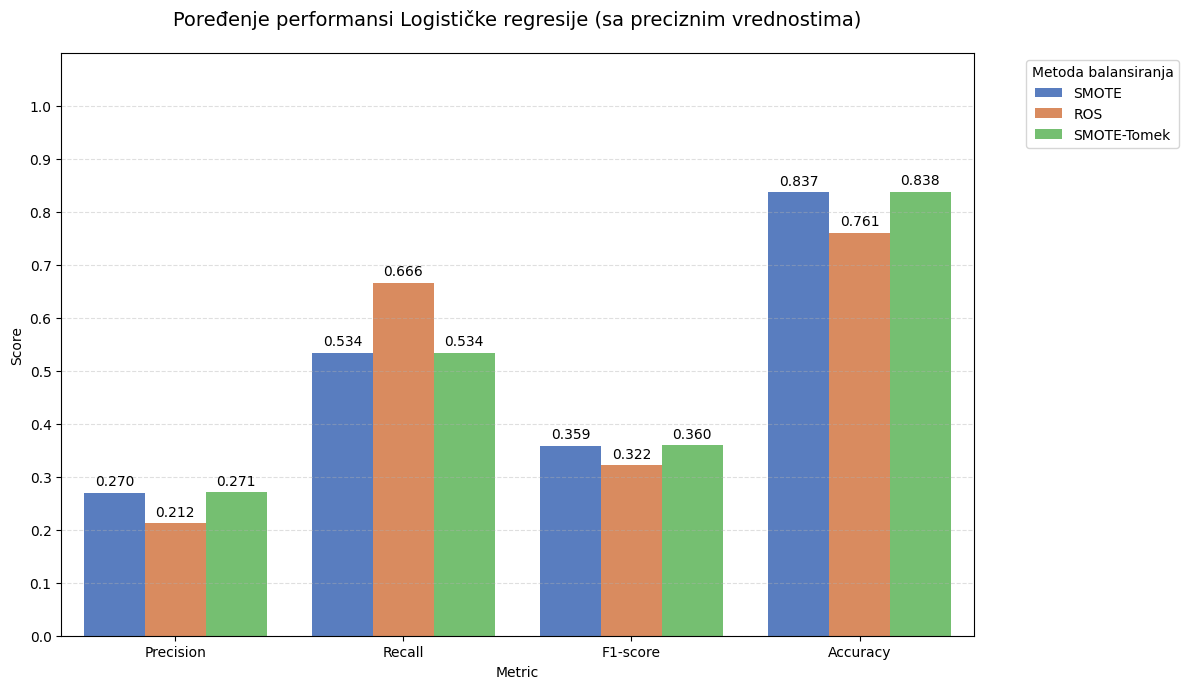

In [750]:
results_melted = results_lr.melt(id_vars="Balancing", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=results_melted, x="Metric", y="Score", hue="Balancing", palette="muted")
plt.yticks(np.arange(0, 1.1, 0.1)) 
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.title("Poređenje performansi Logističke regresije (sa preciznim vrednostima)", fontsize=14, pad=20)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Metoda balansiranja", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

F1-score je glavna metrika, dok su ostale metrike tu da analiziramo ponasanje modela. Sa grafika vidimo da je najvisi f1-score za SMOTE i SMOTE-Tomek i da su priblizno jednaki. Ostale vrednosti ova dve dve tehnike su takodje priblizno jednake.
ROS ima najvisi recall, ali i najnizu preciznost, dakle da model pogadja vise unapredjenih, ali ima i veci broj false pozitive. 
Slicno ponasanje je i za SMOTE i SMOTE-Tomek, sa tim da je recall malo nizi a precision malo visi, pa je i bolji odnos te dve metrike sto se vidi na f1-score vrednosti.
Accuracy je visok za sve tehnike, ali nije merodavna metrika u slucaju nebalansiranosti podataka, pa je ovde da prikaze koliko moze da zavara.
Dakle, Linearna regresija najbolje rezultate postize za SMOTE i SMOTE-Tomek tehnike resavanja nebalansiranosti podataka sa f1-score od 0.38.

## Random Forest

Random Forest je ansambl metoda zasnovana na stablima odlucivanja, koja je pogodna za modelovanje nelinearnih odnosa izmedju promenjivih i zbog svoje robusnosti protiv overfitting-a. 
Model se trenira na prethodno balansiranom trening skupu. Uporedićemo performanse modela na osnovu različitih tehnika balansiranja.

In [751]:
# SMOTE
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)

# ROS
rf_ros = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_ros.fit(X_train_ros, y_train_ros)

# SMOTE-Tomek
rf_st = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_st.fit(X_train_st, y_train_st)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluacija Random Forest modela 

Evaluacija se vrsi na originalnom test skupu, gde je ocuvana realna distribucija klasa.

In [752]:
y_pred_rf_smote = rf_smote.predict(X_test)
y_pred_rf_ros = rf_ros.predict(X_test)
y_pred_rf_st = rf_st.predict(X_test)

results_rf = pd.DataFrame({
    "Balancing": ["SMOTE", "ROS", "SMOTE-Tomek"],
    "Precision": [
        precision_score(y_test, y_pred_rf_smote),
        precision_score(y_test, y_pred_rf_ros),
        precision_score(y_test, y_pred_rf_st)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf_smote),
        recall_score(y_test, y_pred_rf_ros),
        recall_score(y_test, y_pred_rf_st)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_rf_smote),
        f1_score(y_test, y_pred_rf_ros),
        f1_score(y_test, y_pred_rf_st)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf_smote),
        accuracy_score(y_test, y_pred_rf_ros),
        accuracy_score(y_test, y_pred_rf_st)
    ]
})

print(results_rf)

     Balancing  Precision    Recall  F1-score  Accuracy
0        SMOTE   0.505688  0.349286  0.413181  0.915526
1          ROS   0.643631  0.339286  0.444341  0.927750
2  SMOTE-Tomek   0.503553  0.354286  0.415933  0.915283


### Vizuelni prikaz rezultata Random Forest modela za SMOTE, ROS i SMOTE-Tomek tehnike resavanja nebalansiranosti klasa

Vizuelni prikaz poredjenja tri razlicite tehnike za resavanje problema nebalansiranosti:
- SMOTE
- ROS
- SMOTE-Tomek

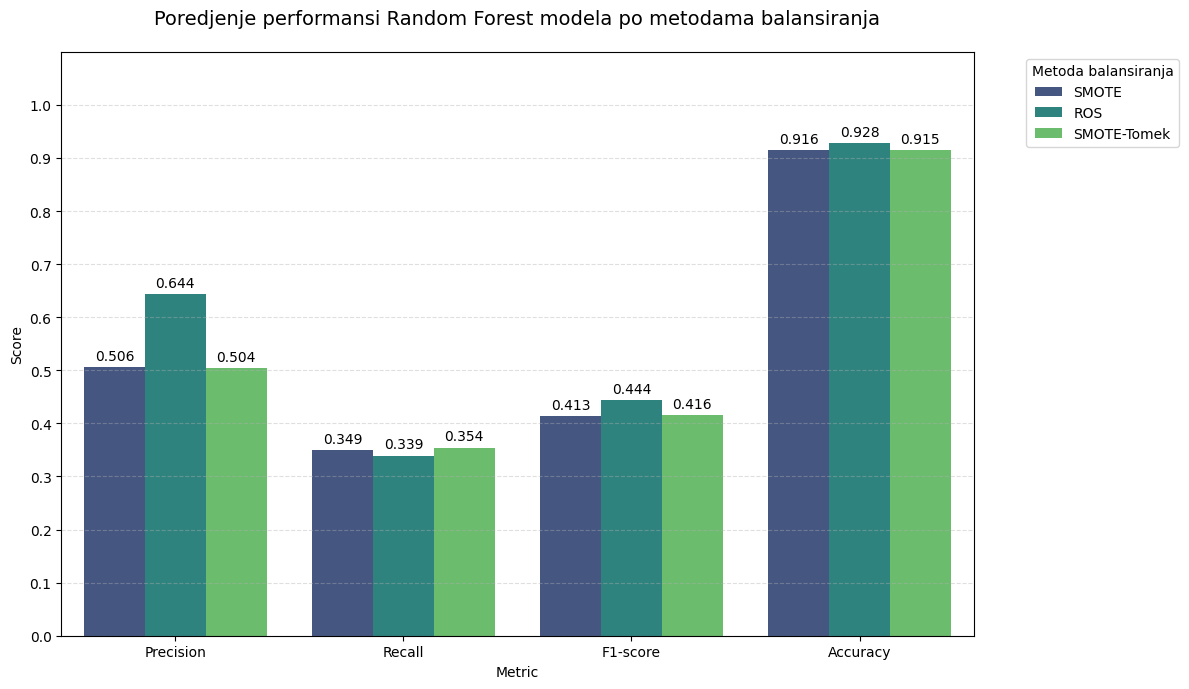

In [753]:
results_rf_melted = results_rf.melt(id_vars="Balancing", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=results_rf_melted, x="Metric", y="Score", hue="Balancing", palette="viridis")
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1.1)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.title("Poredjenje performansi Random Forest modela po metodama balansiranja", fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Metoda balansiranja", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Na grafiku je primetan znacajan skok preciznosti u odnosu na Logisticku regresiju gde je iznosila 0.27 za SMOTE i SMOTE-Tomek, a sada ~0.505, a za ROS 0.212 a sada cak 0.644, sto znaci da je manji broj lazno pozitivnih.<br>
Recall je opao sa ~0.54 na ~0.35, sto znaci da model sada prepoznaje nesto vise od trecine stvarno unapredjenih. <br>
F1-score je porastao sa oko 0.32 za ROS (i 0.36 za SMOTE i SMOTE-Tomek) na 0.444 sto pokazuje bolju balansiranost izmedju preciznosti i odziva u poredjenu sa Logistickom regresijom(sto je i ocekivano jer RF ima mogucnost modelovanja i nelinearnih zavisnosti atributa), sto sugerise da Random Forest daje pouzdanije pozitivne predikcije i bolje balansira lazno pozitivne i lazno negativne rezultate, posebno u kombinaciji sa ROS tehnikom balansiranja.<br>
Tacnost je ponovo jako visoka, ali nije reprezentativna mera uspesnosti modela.

## Gradient Boosting

Gradient Boosting je ansambl metoda koja gradi sekvencijalno stabla odlučivanja, gde svako novo stablo ispravlja greške prethodnih, što omogućava precizno modelovanje složenih i nelinearnih odnosa između promenjivih.

Model se trenira na prethodno balansiranom trening skupovima nastalim primenom tri razlicite tehnike(SMOTE, ROS i SMOTE-Tomek).

In [754]:
# SMOTE
gb_smote = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)
gb_smote.fit(X_train_smote, y_train_smote)

# ROS
gb_ros = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)
gb_ros.fit(X_train_ros, y_train_ros)

# SMOTE-Tomek
gb_st = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)
gb_st.fit(X_train_st, y_train_st)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Evaluacija Gradient Boosting modela

Evaluacija se vrsi na originalnom test skupu, gde je ocuvana realna distribucija klasa.

In [755]:
y_pred_gb_smote = gb_smote.predict(X_test)
y_pred_gb_ros = gb_ros.predict(X_test)
y_pred_gb_st = gb_st.predict(X_test)

# Evaluacija
results_gb = pd.DataFrame({
    "Balancing": ["SMOTE", "ROS", "SMOTE-Tomek"],
    "Precision": [
        precision_score(y_test, y_pred_gb_smote),
        precision_score(y_test, y_pred_gb_ros),
        precision_score(y_test, y_pred_gb_st)
    ],
    "Recall": [
        recall_score(y_test, y_pred_gb_smote),
        recall_score(y_test, y_pred_gb_ros),
        recall_score(y_test, y_pred_gb_st)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_gb_smote),
        f1_score(y_test, y_pred_gb_ros),
        f1_score(y_test, y_pred_gb_st)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_gb_smote),
        accuracy_score(y_test, y_pred_gb_ros),
        accuracy_score(y_test, y_pred_gb_st)
    ]
})

print(results_gb)

     Balancing  Precision    Recall  F1-score  Accuracy
0        SMOTE   0.489215  0.405000  0.443142  0.913337
1          ROS   0.274615  0.623571  0.381306  0.827708
2  SMOTE-Tomek   0.489601  0.403571  0.442443  0.913398


### Vizuelni prikaz rezultata Gradient Boosting modela za SMOTE, ROS i SMOTE-Tomek tehnike resavanja nebalansiranosti klasa

Vizuelni prikaz poredjenja tri razlicite tehnike za resavanje problema nebalansiranosti:
- SMOTE
- ROS
- SMOTE-Tomek

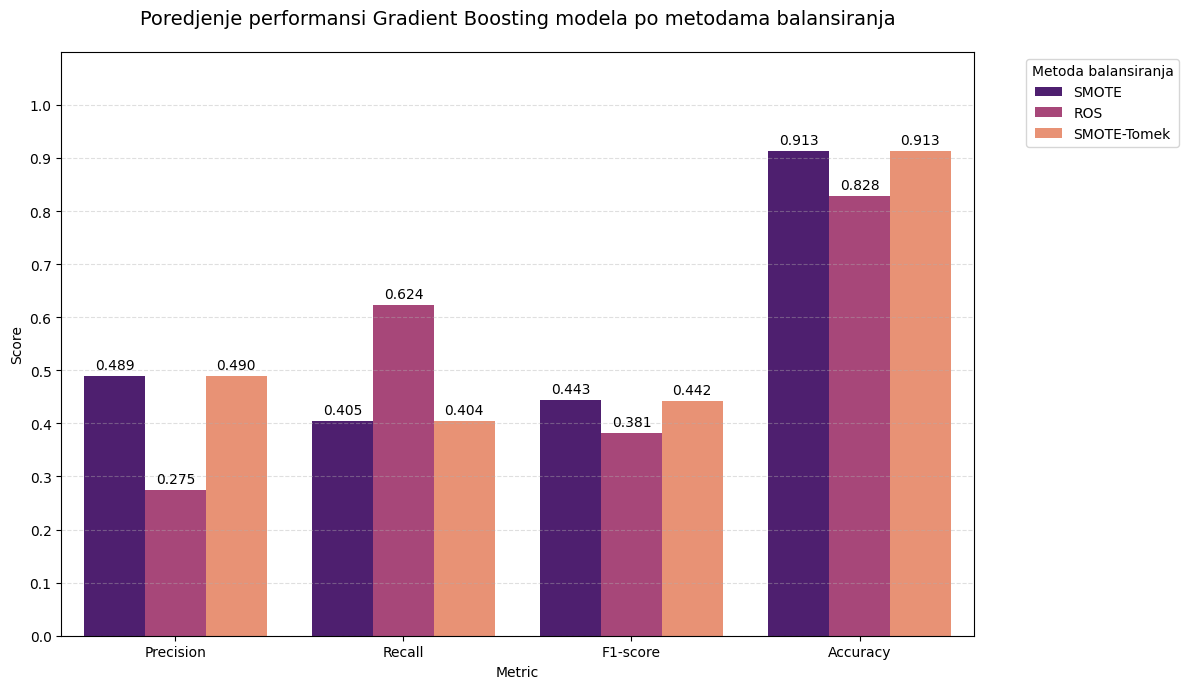

In [756]:
results_gb_melted = results_gb.melt(id_vars="Balancing", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=results_gb_melted, x="Metric", y="Score", hue="Balancing", palette="magma")
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1.1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.title("Poredjenje performansi Gradient Boosting modela po metodama balansiranja", fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Metoda balansiranja", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Gradient Boosting postize uravnotezenije performanse u identifikaciji unapredjenih zaposlenih u poredjenju sa Logistickom regresijom, ali i u nekim aspektima slicno Random Forest-u. <br> 
Odziv modela varira izmedju 0.40–0.62, gde ROS daje najveci odziv (0.62), ali uz nisku preciznost (0.27), sto znaci veliki broj lazno pozitivnih predikcija. <br> 
SMOTE i SMOTE-Tomek daju bolju preciznost (~0.49) uz nesto nizi odziv (~0.40), sto rezultira boljim balansom izmedju preciznosti i odziva. F1-score iznosi 0.44 za SMOTE i SMOTE-Tomek, dok ROS daje 0.38, sto ukazuje da je najbolje balansirana kombinacija Gradient Boosting sa SMOTE tehnikom, slicno kao sto je Random Forest najbolje funkcionisao sa ROS-om. <br> Tacnost (~0.91) opet nije pouzdana zbog nebalansirane distribucije klasa, pa se F1-score koristi kao glavna metrika evaluacije.
<br>
Iako su f1-score vrednosti nize nego kod Random Foresta, Gradient Boosting pokazuje bolju stabilnost preciznosti u odnosu na linearni model, sto je dokaz da su Boosting algoritmi adekvatniji za ovaj set podataka.

## XGBoost

XGBoost je ansambl metoda zasnovana na gradijentnom pojačavanju stabala odluka, koja kombinuje više slabih stabala kako bi dobila snažan prediktivni model i efikasno hvata nelinearne odnose između promenljivih, uz dobru kontrolu overfitting-a.

Model se trenira na prethodno balansiranom trening skupu. Uporedićemo performanse modela na osnovu različitih tehnika balansiranja.

In [757]:
# SMOTE
xgb_smote = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)

# ROS
xgb_ros = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_ros.fit(X_train_ros, y_train_ros)

# SMOTE-Tomek
xgb_st = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_st.fit(X_train_st, y_train_st)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### Evaluacija XGBoost modela

Evaluacija se vrsi na originalnom test skupu, gde je ocuvana realna distribucija klasa.

In [758]:
y_pred_xgb_smote = xgb_smote.predict(X_test)
y_pred_xgb_ros = xgb_ros.predict(X_test)
y_pred_xgb_st = xgb_st.predict(X_test)

results_xgb = pd.DataFrame({
    "Balancing": ["SMOTE", "ROS", "SMOTE-Tomek"],
    "Precision": [
        precision_score(y_test, y_pred_xgb_smote),
        precision_score(y_test, y_pred_xgb_ros),
        precision_score(y_test, y_pred_xgb_st)
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb_smote),
        recall_score(y_test, y_pred_xgb_ros),
        recall_score(y_test, y_pred_xgb_st)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_xgb_smote),
        f1_score(y_test, y_pred_xgb_ros),
        f1_score(y_test, y_pred_xgb_st)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_xgb_smote),
        accuracy_score(y_test, y_pred_xgb_ros),
        accuracy_score(y_test, y_pred_xgb_st)
    ]
})

print(results_xgb)

     Balancing  Precision    Recall  F1-score  Accuracy
0        SMOTE   0.798107  0.361429  0.497542  0.937846
1          ROS   0.297071  0.557857  0.387689  0.849967
2  SMOTE-Tomek   0.793375  0.359286  0.494592  0.937481


### Vizuelni prikaz rezultata XGBoost modela za SMOTE, ROS i SMOTE-Tomek tehnike resavanja nebalansiranosti klasa

Vizuelni prikaz poredjenja tri razlicite tehnike za resavanje problema nebalansiranosti:
- SMOTE
- ROS
- SMOTE-Tomek

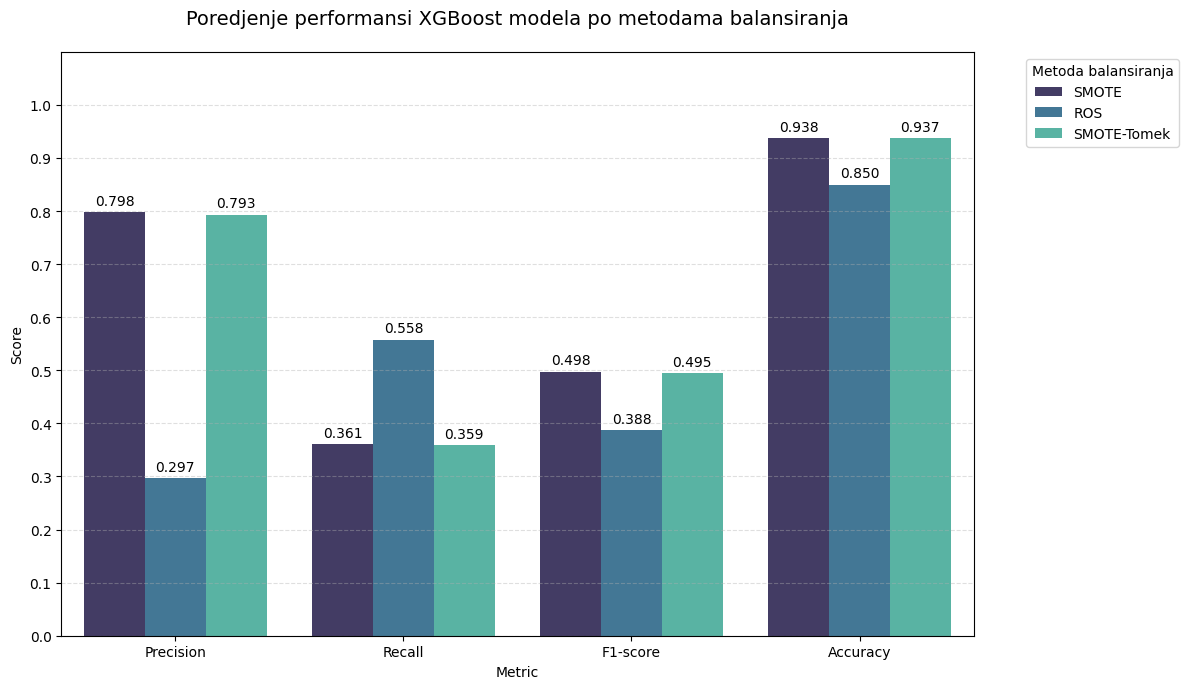

In [759]:
results_xgb_melted = results_xgb.melt(id_vars="Balancing", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=results_xgb_melted, x="Metric", y="Score", hue="Balancing", palette="mako")
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1.1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.title("Poredjenje performansi XGBoost modela po metodama balansiranja", fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Metoda balansiranja", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

XGBoost pokazuje slicno ponasanje sa tehnikama resavanja nebalansiranosti kao Gradient Boosting model. SMOTE i SMOTE-Tomek ponovo imaju najbolje rezultate i vrednosti metrika su im priblizno jednake. Postizu preciznost od ~0.8 sto znaci da model pogresno predvidi unapredjene u samo 20% slucajeva. Odziv od 0.36 predstavlja da model nadje tek nesto vise od trecine unapredjenih, ali uz preciznost od ~0.8 znaci da one koje pronadje su sa velikom verovatnocom tacni. <br>
ROS ponovo pokazuje znacajno drugaciji balans, niza preciznost od 0.297, ali veci odziv od 0.557, i f1-score od 0.388. Ovo potvrdjuje da cisto dupliranje podataka dovodi do veceg broja lazno pozitivnih rezultata, dok sinteticki unos novih zapisa kod SMOTE i SMOTE-Tomek tehnika ima znacajno bolji balans preciznosti i odziva sa f1-score od ~0.5. <br>

## Poredjenje performansi svih modela
Poredimo cetiri razlicita algoritma (Logisticka regresija, Random Forest, Gradient Boosting, XGBoost) u kombinaciji sa tri tehnike balansiranja klasa (SMOTE, ROS, SMOTE-Tomek). Cilj je identifikovati najbolju kombinaciju modela i tehnike resavanja nebalansiranosti podataka na osnovu vrednosti f1-score metrike.

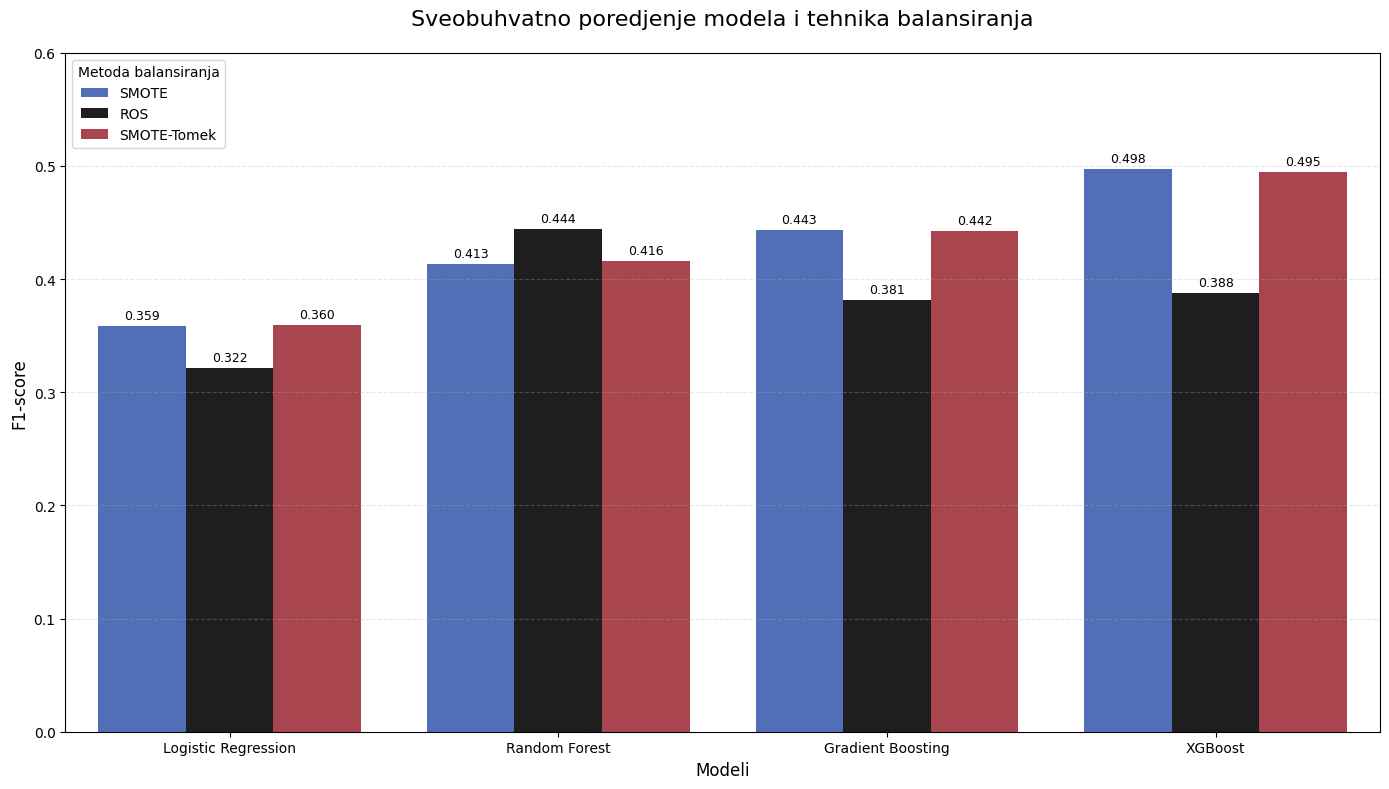

In [760]:
results_lr['Model'] = 'Logistic Regression'
results_rf['Model'] = 'Random Forest'
results_gb['Model'] = 'Gradient Boosting'
results_xgb['Model'] = 'XGBoost'

all_results = pd.concat([results_lr, results_rf, results_gb, results_xgb])
plt.figure(figsize=(14, 8))
ax = sns.barplot(data=all_results, x='Model', y='F1-score', hue='Balancing', palette='icefire')
plt.yticks(np.arange(0, 0.7, 0.1))
plt.ylim(0, 0.6)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.title("Sveobuhvatno poredjenje modela i tehnika balansiranja", fontsize=16, pad=20)
plt.ylabel("F1-score", fontsize=12)
plt.xlabel("Modeli", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title="Metoda balansiranja", loc='upper left')

plt.tight_layout()
plt.show()

Modeli bazirani na stablima odlucivanja znacajno nadmasuju linearnu Logisticku regresiju, sto je i ocekivano, ali ovim i potvrdjeno da su obrasci unapredjenja zaposlenih nelinearni.<br>
Interesantno je da ROS kod svih modela tezi da poveca recall, ali drasticno urusava f1-score zbog pada preciznosti.<br>
SMOTE i SMOTE-Tomek su imali vise vrednosti f1-score i pokazali su bolju balansiranost odziva i preciznosti. <br>

XGBoost je model sa najboljim rezultatima f1-score metrike, s tim da je razlika u performaksama izmedju SMOTE i SMOTE-Tomek metoda od 0.498 i 0.495 mala. Iako SMOTE-Tomek uklanja sum i pravi jasnije granice odlucivanja izmedju klasa, razlika  u rezultatima je zanemarljiva i ukazuje na to da su klase u ovom skupu podataka relativno jasno definisane. 

Dosadasnji rezultati su pokazali da su nelinearni modeli neophodni za resavanje ovog problema.
Kao najbolji model i tehnika resavanja nebalansiranosti podataka se izdvajaju XGBoost + SMOTE sa f1-score vrednoscu od 0.498, i ovaj model je izabran za dalju optimizaciju. Da bismo osigurali da model nije prilagodjen podacima i da su njegovi rezultati optimalni, u nastavku sprovodimo:
- Grid Search uz k-fold unakrsnu validaciju, koji ce sistematicno ispitati kombinacije hiperparametara kroz 5 razlicitih podskupova podataka. Ovo radimo u svrhu potvrdjivanja da postignuta vrednost f1-score metrike nije rezultat slucajnosti u podeli skupova
- feature importance, gde se nakon pronalaska najbolje verzije modela pomogu Grid Search tehnike analizira znacaj atributa nad finalnim optimizovanim modelom. 


# Optimizacija hiperparametara za XGBoost + SMOTE primenom Grid Search i unakrsne validacije

XGBoost je model koji je uz SMOTE imao nejbolji rezultat, i samim tim najveci potencijal. Da bi se izvukle maksimalne performanse izvrseno je podesavanje njegovih hiperparametara.
Koristimo Grid Search sa unakrsnom validacijom u kombinaciji sa pipeline stukturom, da osiguramo da se SMOTE resampling desava samo unutar trening foldova tokom unakrsne validacije i da proces balansiranja klase bude izolovan od testnog folda. Koristimo 5-fold unakrsnu validaciju, gde se svaka kombinacija parametara testira na 5 razlicitih podela podataka da bi se potvrdila stabilnost modela.

In [761]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
])

param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_xgb_model = grid_search.best_estimator_

print(f"Najbolji parametri: {grid_search.best_params_}")
print(f"Najbolji CV F1-score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Najbolji parametri: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 7, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}
Najbolji CV F1-score: 0.4943


Dobijeni rezulteti Grid Search + cross-calidation procesa predstavljaju optimalan skup hiperparametara koji maksimizuje f1-score.
Vrednost unakrsne validacije od 0.4943 je dobijena kao prosek pet razlicitih krugova testiranja i potvrdjuje da model stabilno identifikuje kandidate iako je prisutna velika neuravnotezenost ciljne klase.

 ## Finalna evaluacija XGBoost + SMOTE modela 

Nakon identifikacije optimalnih hiperparametara izvrsena je finalna evaluacija modela na testnom skupu podataka. 

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     15043
           1       0.77      0.35      0.49      1400

    accuracy                           0.94     16443
   macro avg       0.86      0.67      0.73     16443
weighted avg       0.93      0.94      0.92     16443



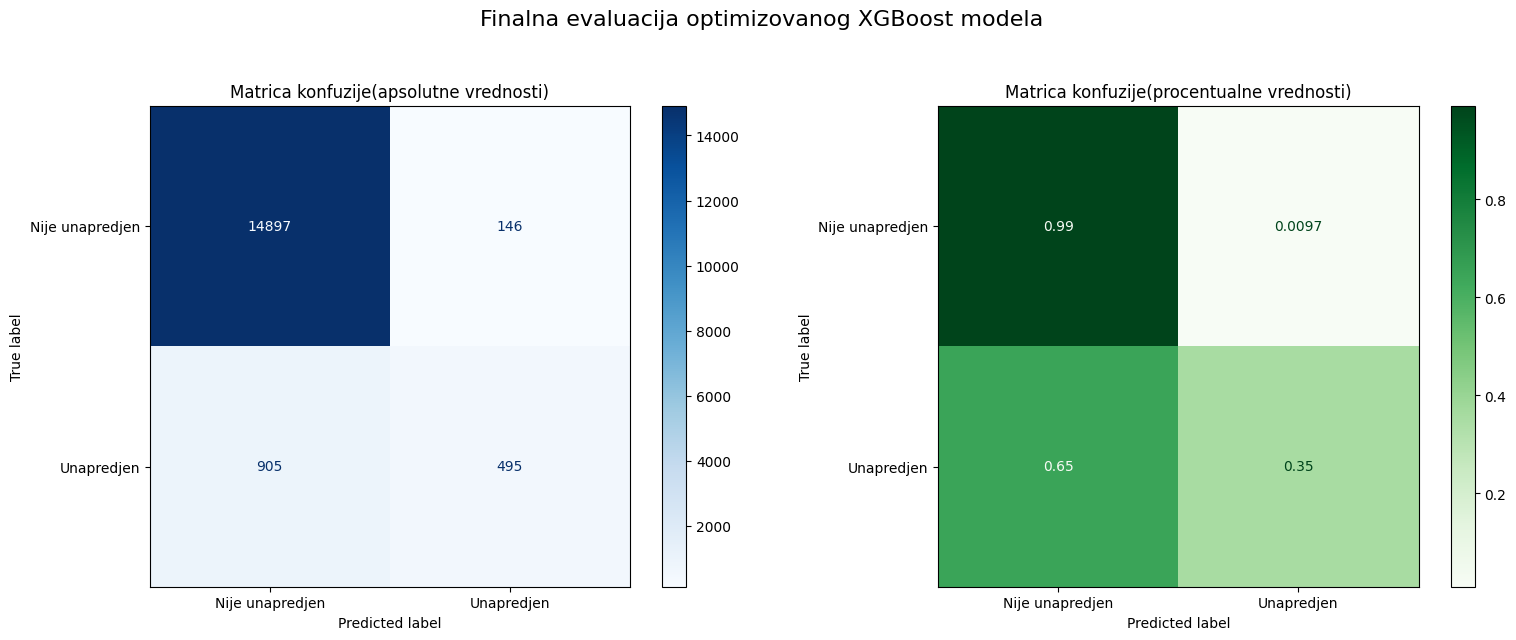

In [762]:
y_pred_final = best_xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_final))
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, 
                                        display_labels=['Nije unapredjen', 'Unapredjen'],
                                        cmap='Blues', ax=ax[0])
ax[0].set_title("Matrica konfuzije(apsolutne vrednosti)")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, 
                                        display_labels=['Nije unapredjen', 'Unapredjen'],
                                        cmap='Greens', normalize='true', ax=ax[1])
ax[1].set_title("Matrica konfuzije(procentualne vrednosti)")

plt.suptitle("Finalna evaluacija optimizovanog XGBoost modela", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Finalna evaluacija optimizovanog XGBoost modela prikazuje visoku selektivnost i pouzdanost u predikciji unapredjenja. Model je dostigao preciznost od 77%, a odziv pokazuje da hvata 35% svih unapredjenih. F1-score iznosi 0.49 sto je bilo ocekivano. Model pronalazi najsigurnije kandidate za unapredjenje, a greska kod neunapredjenih radnika iznosi manje od 1%.

# Feature Importance
Koristimo best_xgb_model dobijen nakon optimizacije hiperparametara kako bismo identifikovali faktore koji najvise uticu na unapredjenje.

                         Atribut  Importance
0           previous_year_rating    0.093987
1   department_Sales & Marketing    0.076098
2                    awards_won?    0.065668
3              length_of_service    0.043563
4          department_Operations    0.039503
5             avg_training_score    0.036378
6                region_region_4    0.034075
7               region_region_34    0.031774
8                            age    0.027711
9               region_region_22    0.027472
10              region_region_23    0.023497
11               region_region_7    0.022039
12  recruitment_channel_referred    0.020886
13        department_Procurement    0.020167
14              region_region_28    0.019885


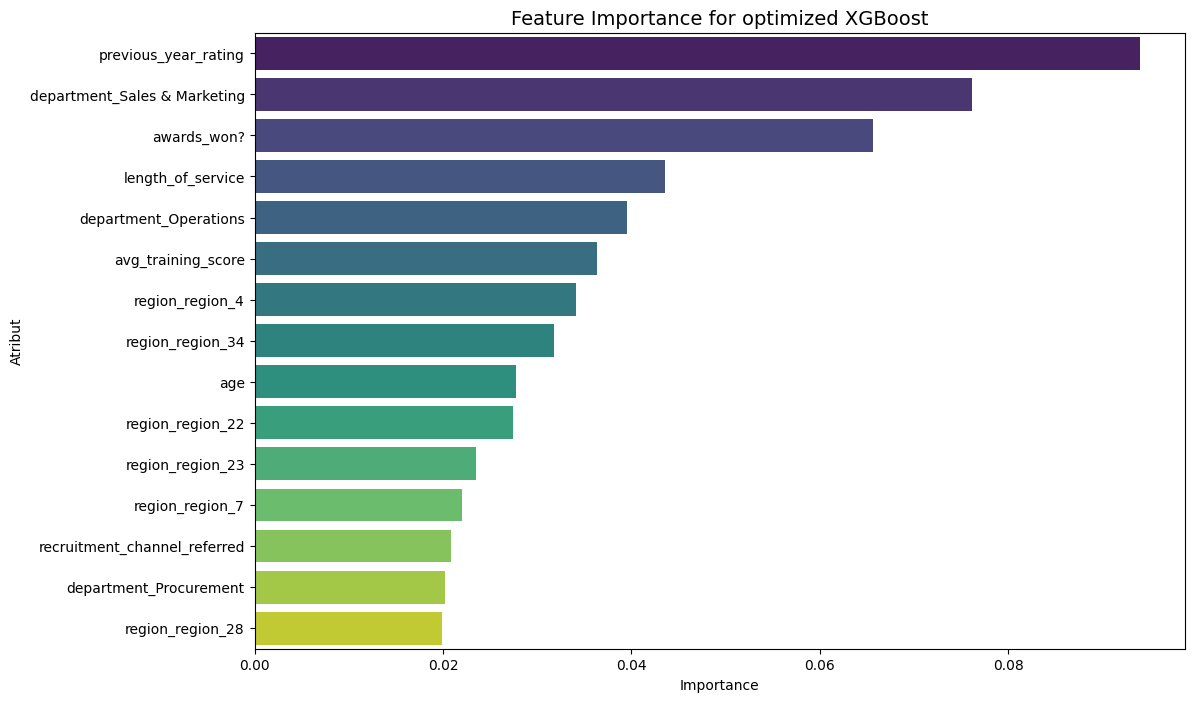

In [763]:
final_xgb = best_xgb_model.named_steps['xgb']
feat_imp_df = pd.DataFrame({
    'Atribut': X_train.columns,
    'Importance': final_xgb.feature_importances_
})

feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
print(feat_imp_df.head(15))
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Atribut', data=feat_imp_df.head(15), palette='viridis', hue='Atribut', legend=False)
plt.title("Feature Importance for optimized XGBoost", fontsize=14)
plt.show()

Na grafiku je prikazan uticaj atributa na optimizovani XGBoost model.
Najznacajniji faktor za unapredjenje je ocena iz prethodne godine sa 9,4%. Od usticajnih obelezja se jos istice broj osvojenig nagrada, duzina radnog staza, prosecna ocena treninga i starost zaposlenog. Osim ovih obelezja, isticu se i zaposleni iz departmana Sales & Marketing i Operations.

# Feature Engineering

U ovom poglavlju je primenjen feature engineering zasnovan na referentnom radu https://dergipark.org.tr/en/download/article-file/3876313. Fokus je na transformaciji podataka stvarajuci nova obelezja koja povezuju postojeca. Uvedeno je grupisanje godina i rezultata treninga i kreiranje nove metrike performance indeksa. Cilj je istrazivanje ponasanja modela nad transformisanim skupom podataka.

In [764]:
X_train_ref = X_train.copy()
X_test_ref = X_test.copy()

def apply_ref_engineering(df):
    cols_to_fix = ['previous_year_rating', 'avg_training_score', 'no_of_trainings', 'length_of_service', 'age']
    for col in cols_to_fix:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    df['sum_metric'] = df['awards_won?'] + df['previous_year_rating']
    df['total_score'] = df['no_of_trainings'] * df['avg_training_score']
    df['total_score_cat'] = pd.cut(df['total_score'], 
                                   bins=[-1, 65, 145, np.inf], 
                                   labels=[0, 1, 2])
    df['total_score_cat'] = df['total_score_cat'].fillna(0).astype(int)
    df['work_fraction'] = df['length_of_service'] / (df['age'] + 1e-6)
    df['years_to_retire'] = 65 - df['age']
    df['work_start_year'] = df['age'] - df['length_of_service']
    df['performance'] = ((df['previous_year_rating'] >= 4) | (df['awards_won?'] == 1)).astype(int)
    df['age_group'] = (df['age'] // 5).fillna(0).astype(int)
    
    return df

X_train_ref = apply_ref_engineering(X_train_ref)
X_test_ref = apply_ref_engineering(X_test_ref)

Kreira se novi skup sa obelezjima na osnovu rezultata inicijalnog pretprocesiranja. Sve numericke nedostajuce vrednosti su zamenjene medijanom. <br>
Napravljeni su novi atributi koji kombinuju vise faktora:
- sum_metric: sabira nagrade i ocenu, da se prepoznaju zaposleni koji su konstantno dobri i nagradjivani
- total_score: proizvod broja obuka i prosecne ocene na obukama, da se razlikuju zaposleni koji su prosli kroz mnogo obuka sa dobrim rezultatima, od onih koji nisu
- performance: binarni indikator onih koji imaju ocenu iz prethodne godine 4 ili vise

Grupisanje, da se smanji sum u podacima koji imaju slicnu vrednost:
- total_score_cat: novokreirani total_score je podaljen po kategorijama
- age_group: starost je grupisana na svakih 5 godina

Mere trenutne faze karijere zaposlenog:
- work_friction: odnos radnog staza i godina zivota
- years_to_retire i work_start_year: pomazu modelu da shvati u kojoj fazi karijere je zaposleni

### Priprema podataka za modelovanje
Prvo su izbacene kolone za koje refernetni rad kaze da su nebitne, a koje se nisu nasle u feature importance analizi. Uradjena je standardizacija, gde su svi podaci normalizovani, a zatim je primenjena SMOTE tehnika za resavanje problema nebalansiranosti ciljne klase, a koja se najbolje pokazala u dosadasnjem radu.

In [765]:
X_train_ref_final = pd.get_dummies(X_train_ref, drop_first=True)
X_test_ref_final = pd.get_dummies(X_test_ref, drop_first=True)
X_train_ref_final, X_test_ref_final = X_train_ref_final.align(X_test_ref_final, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ref_final)
X_test_scaled = scaler.transform(X_test_ref_final)

smote = SMOTE(random_state=42)
X_res_ref, y_res_ref = smote.fit_resample(X_train_scaled, y_train)

Nakon transformacije je dobijen finalni skup podataka (X_res_ref, y_res_ref) spreman za trening XGBoost modela.

In [766]:
xgb_ref = XGBClassifier(
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.1, 
    subsample=0.8, 
    random_state=42, 
    eval_metric='logloss'
)

xgb_ref.fit(X_res_ref, y_res_ref)
y_pred_ref = xgb_ref.predict(X_test_scaled)
print(classification_report(y_test, y_pred_ref))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     15043
           1       0.86      0.31      0.46      1400

    accuracy                           0.94     16443
   macro avg       0.90      0.65      0.71     16443
weighted avg       0.93      0.94      0.92     16443



### Poredjenje inicijalnog optimizovanog XGBoosta i unapredjenog upotrebom feature engineering-a

Nakon primene XGBoost modela uz feature engineering prikazujemo finalno poredjenje inicijalnog optimizovanog XGBoost modela i unapredjneog upotrebom feature engineering-a. 

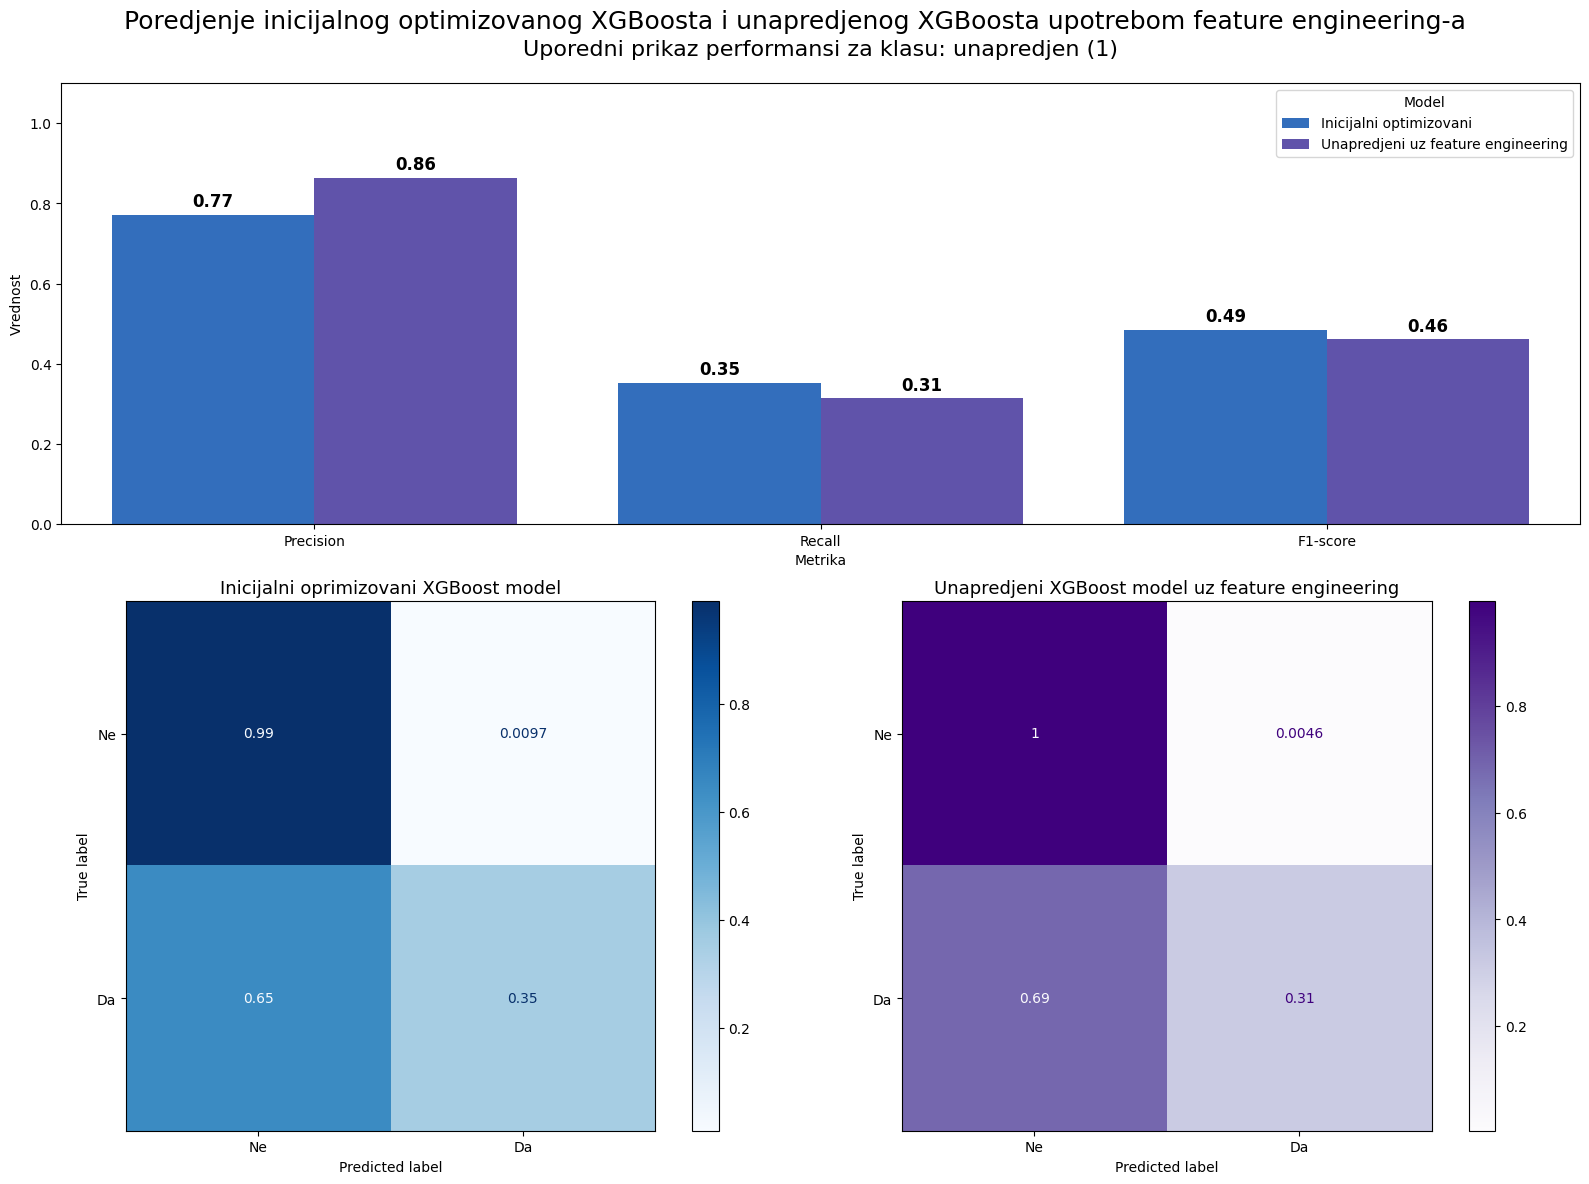

In [767]:
res_initial = precision_recall_fscore_support(y_test, y_pred_final, average=None)
res_ref = precision_recall_fscore_support(y_test, y_pred_ref, average=None)
data = {
    'Metrika': ['Precision', 'Recall', 'F1-score'] * 2,
    'Vrednost': [res_initial[0][1], res_initial[1][1], res_initial[2][1], 
                 res_ref[0][1], res_ref[1][1], res_ref[2][1]],
    'Model': ['Inicijalni optimizovani'] * 3 + ['Unapredjeni uz feature engineering'] * 3
}
df_metrics = pd.DataFrame(data)
custom_palette = {"Inicijalni optimizovani": "#1c6bd3", "Unapredjeni uz feature engineering": "#5644b9"}

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

ax1 = fig.add_subplot(gs[0, :])
sns.barplot(data=df_metrics, x='Metrika', y='Vrednost', hue='Model', palette=custom_palette, ax=ax1)
ax1.set_title("Uporedni prikaz performansi za klasu: unapredjen (1)", fontsize=16, pad=20)
ax1.set_ylim(0, 1.1)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3, fontsize=12, fontweight='bold')

ax2 = fig.add_subplot(gs[1, 0])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, display_labels=['Ne', 'Da'], 
                                        cmap='Blues', normalize='true', ax=ax2)
ax2.set_title("Inicijalni oprimizovani XGBoost model", fontsize=13)

ax3 = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ref, display_labels=['Ne', 'Da'], 
                                        cmap='Purples', normalize='true', ax=ax3)
ax3.set_title("Unapredjeni XGBoost model uz feature engineering", fontsize=13)

plt.suptitle("Poredjenje inicijalnog optimizovanog XGBoosta i unapredjenog XGBoosta upotrebom feature engineering-a", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

Na osnovu grafika vidimo skok preciznosti sa 0.77 na 0.86, sto znaci da je model postao znatno sigurniji, sa smanjenim brojem lazno pozitivnih rezultata. <br>
Odziv se smanjio sa 0.35 na 0.31, sto je ocekivano zbog precision-recall trade-off. <br>
f1-score se smanjio sa 0.49 na 0.46, sto je posledica smanjenja odziva, ali je zanemarljiv jer je preciznost modela povecana.

Na konfuzionim matreicama jevidljivo da je nakon unapredjenosti modela, model naucio specificne obrasce zahvaljujuci feature engineeringu, gde je poboljsao rezultate predikcije vecinske klase.

### Feature importance unapredjnog modela

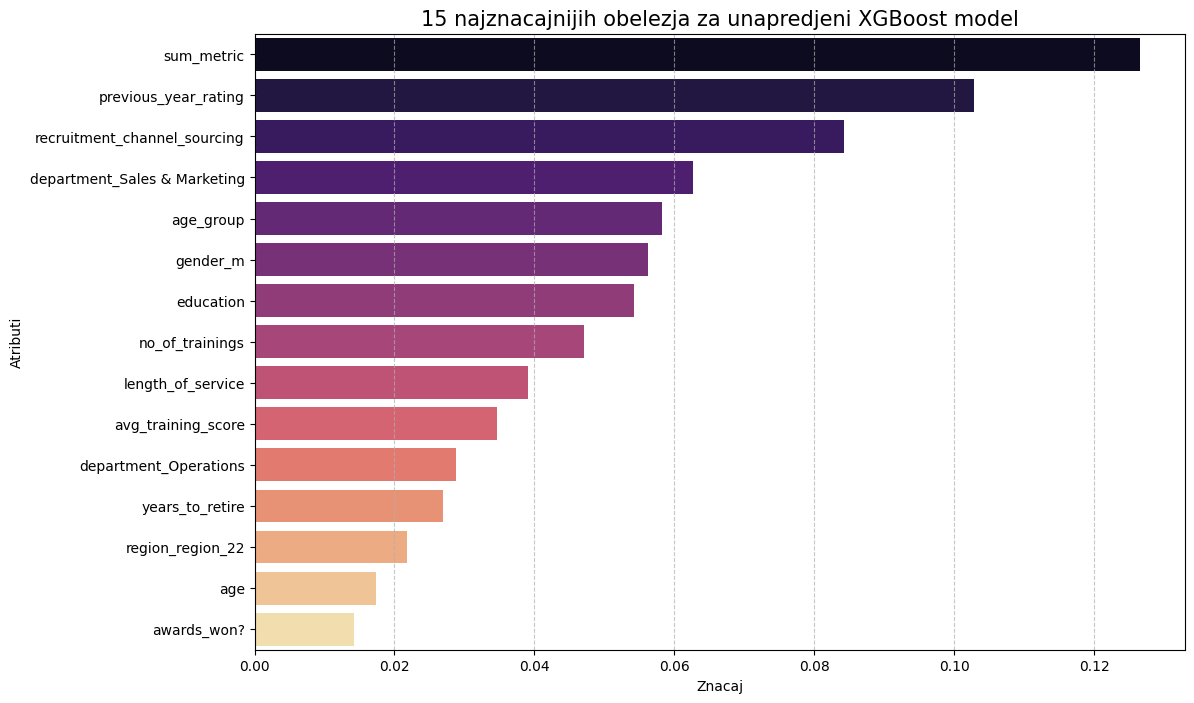

5 najvaznijih faktora za unapredjenje:
                         Atribut    Znacaj
51                    sum_metric  0.126602
3           previous_year_rating  0.102826
50  recruitment_channel_sourcing  0.084192
13  department_Sales & Marketing  0.062727
58                     age_group  0.058283


In [768]:
importances = xgb_ref.feature_importances_
feature_names = X_train_ref_final.columns

feat_imp_df = pd.DataFrame({'Atribut': feature_names, 'Znacaj': importances})
feat_imp_df = feat_imp_df.sort_values(by='Znacaj', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Znacaj', y='Atribut', data=feat_imp_df, palette='magma', hue='Atribut', legend=False)
plt.title("15 najznacajnijih obelezja za unapredjeni XGBoost model", fontsize=15)
plt.xlabel("Znacaj")
plt.ylabel("Atributi")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("5 najvaznijih faktora za unapredjenje:")
print(feat_imp_df.head(5))

Kao 5 najznacajnijih faktora su se izdvojili: 
- sum_metric: nas kreirani atribut kao zbir ocena + nagrada, koji su se i pre izdvajali prema vaznosti 
- previous_year_rating: ocena iz prethodne godine se i dalje nalazi na listi najznacajnijih atributa
- recruitment_channel_sourcing i department_Sales & Marketing: ponovo nestandardni atributi koje model prepoznaje da imaju visok uticaj na unapredjenje
- age_group: grupisanje kandidata prema starosnim kategorijama se pokazalo znacajno za uticaj na unapredjenje

Analiza kljucnih obelezja je potvrdila da feature engineering ima znacajan uticaj na poboljsanje performansi modela, gde su se novokreirani atributi nasli u vrhu znacajnih atributa.

# Zakljucak
Sprovedeno istrazivanje je potvrdilo da su napredni algoritmi zasnovani na stablima odlucivanja superiorniji u resavanju problema predvidjanja sanse unapredjenja zaposlenih u poredjenju sa linearnim modelima. Poredjeni su rezultati modela Logisticke regresije(bazni model), Random Foresta, Gradient Boostinga i XGBoost modela.

Najveci izazov ovog rada je bila ekstremna nebalansiranost ciljne klase, cije je resavanje ispitano primenom SMOTE, ROS i SMOTE-Tomek tehnika.

Najbolji rezultat pre feature engineeringa je imala primena XGBoost + SMOTE modela, sa f1-score 0.49, odzivom 0.35 i preciznoscu 0.77 za pozitivnu klasu. Za negativnu klasu, koja je i vecinska, model je imao f1-score od 0.97 sto je i ocekivano, ali vredno napomenuti.
Kao kljucni faktori unapredjena se izdvajaju ocene iz prethodne godine, osvojene nagrade, duzina radnog staza i prosecna ocena na treninzima.

Nakon primene feature engineeringa inspirisanim referentnim radom, preciznost je porasla sa 0.77 na 0.86, dok se odziv promenio na 0.31 i f1-score na 0.46. Iako je primetan blagi pad odziva i f1-score vrednosti, performanse modela u preciznosti su znatno povecane. 
Nakon feature engineeringa kao kljucne faktore unapredjenja XGBoost je prepoznao novokreiranu metriku sum_metric(ocena + nagrade), ocenu iz prethodne godine kao i uticaj specificnih sektora kojima zaposleni pripadaju.
